In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Device: cuda
BRAIN TUMOR CLASSIFICATION WITH 3-PANEL GRAD-CAM
Classes: ['glioma', 'meningioma', 'pituitary', 'notumor']
Loaded 5600 images from /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Loaded 1600 images from /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing

Training samples: 5600
Testing samples: 1600
Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 164MB/s]



Model parameters: 13,339,012

TRAINING MODEL



Epoch 1/30 [Test]: 100%|██████████| 50/50 [00:10<00:00,  4.81it/s]



Epoch 1/30
  Train Loss: 0.4572 | Train Acc: 0.8293
  Test Loss:  1.6478 | Test Acc:  0.5850


...


Epoch 9/30
  Train Loss: 0.1236 | Train Acc: 0.9589
  Test Loss:  0.5558 | Test Acc:  0.8906


Epoch 10/30 [Test]: 100%|██████████| 50/50 [00:06<00:00,  7.23it/s]



Epoch 10/30
  Train Loss: 0.1019 | Train Acc: 0.9637
  Test Loss:  0.5596 | Test Acc:  0.9181

Early stopping at epoch 10

MODEL EVALUATION



Evaluating: 100%|██████████| 50/50 [00:06<00:00,  7.25it/s]



EVALUATION METRICS:
   Accuracy:  0.9181
   Precision: 0.9299
   Recall:    0.9181
   F1 Score:  0.9156
Saved: training_curves.png
Saved: confusion_matrix.png
Saved: roc_curves.png


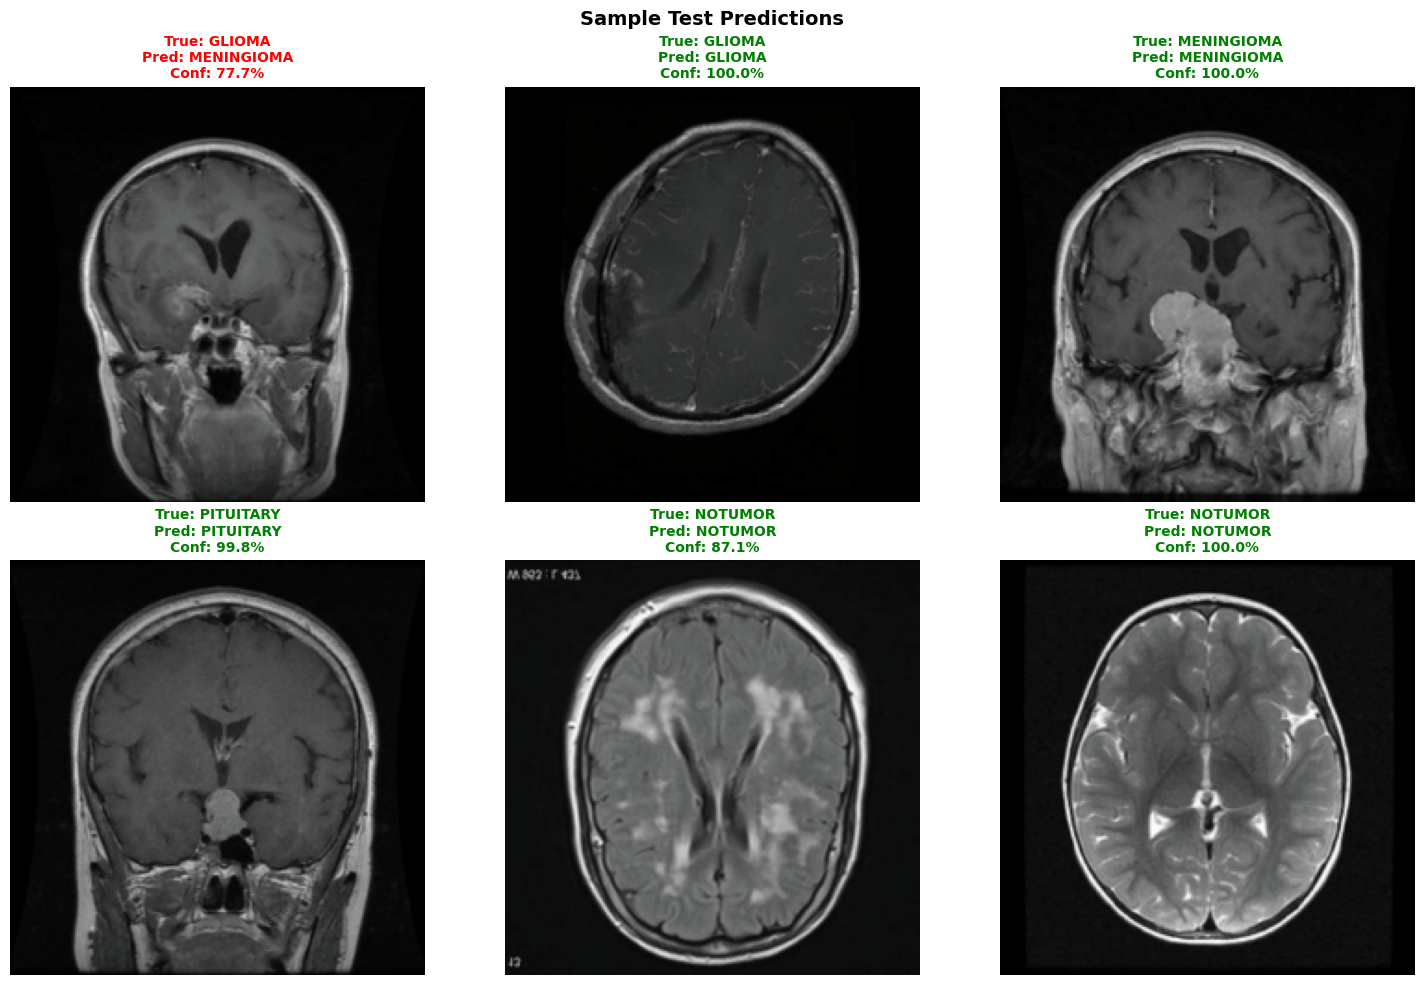

Saved: /kaggle/working/sample_predictions.png

GENERATING 3-PANEL GRAD-CAM WITH TUMOR LOCALIZATION
Panel 1: Original MRI
Panel 2: Grad-CAM Heatmap (Red = Tumor)
Panel 3: OVERLAY (Tumor highlighted on MRI)

Saved: /kaggle/working/gradcam_3panel_results/3panel_sample_1_glioma_pred_meningioma.png


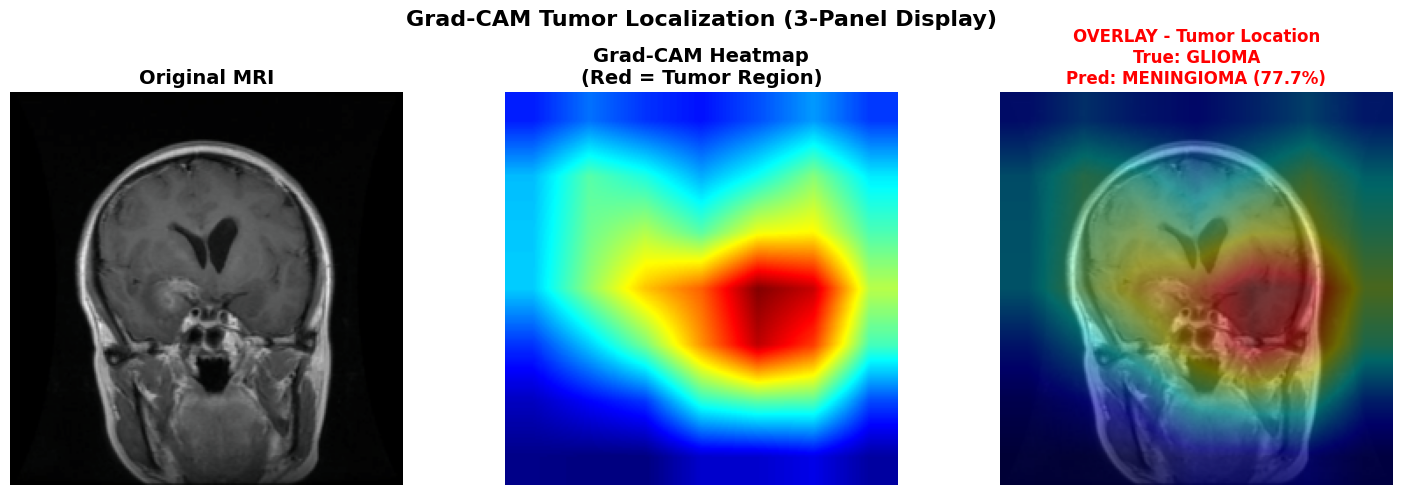

Saved: /kaggle/working/gradcam_3panel_results/3panel_sample_2_meningioma_pred_meningioma.png


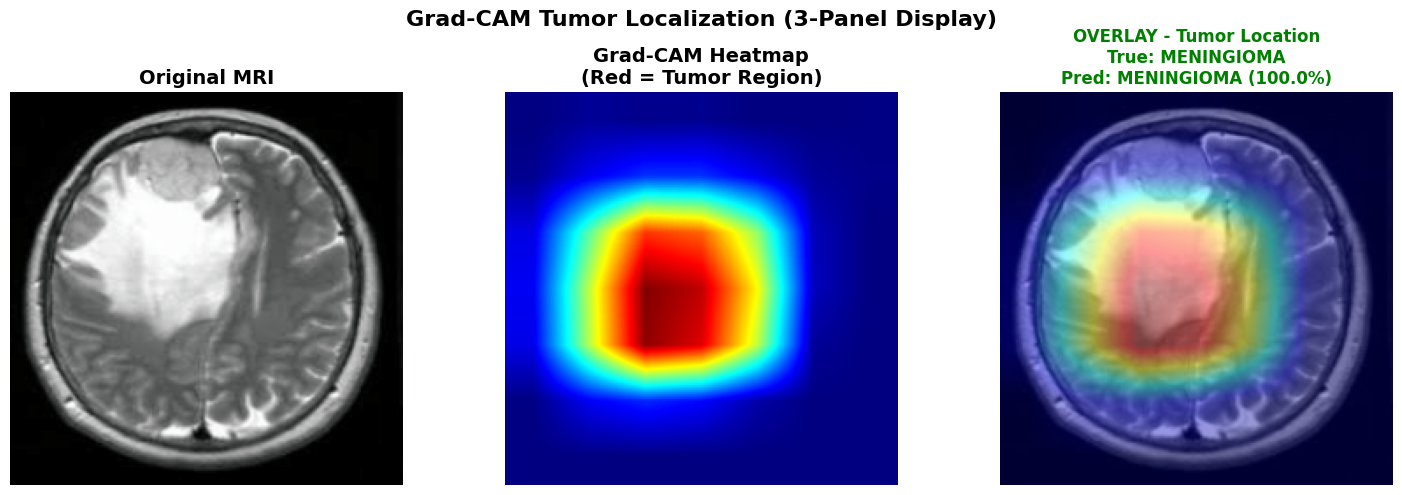

Saved: /kaggle/working/gradcam_3panel_results/3panel_sample_3_pituitary_pred_pituitary.png


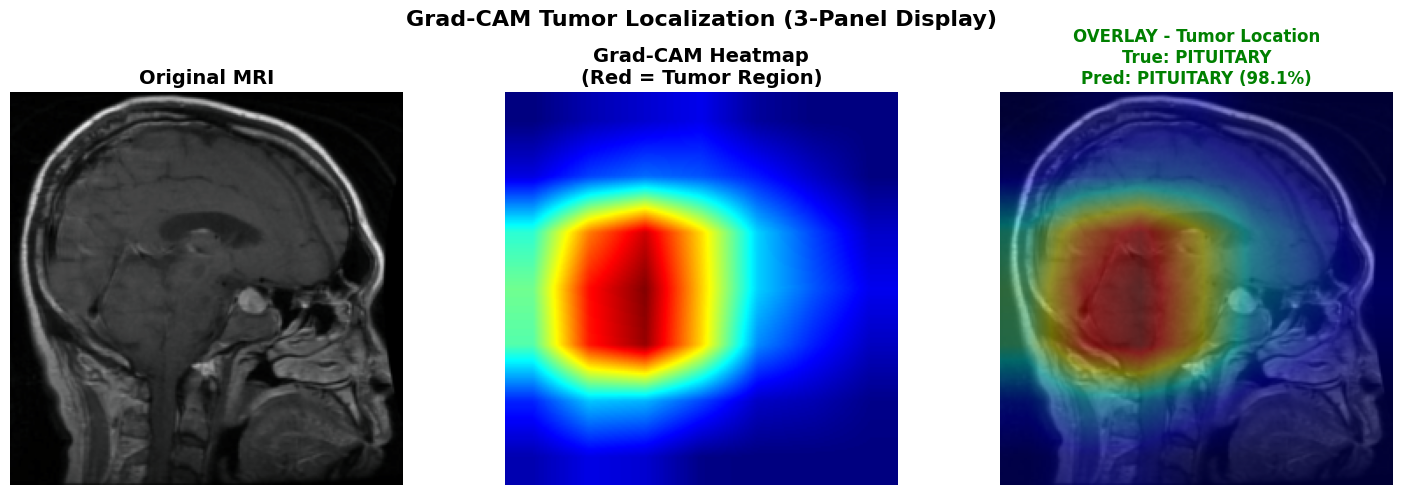

Saved: /kaggle/working/gradcam_3panel_results/3panel_sample_4_notumor_pred_notumor.png


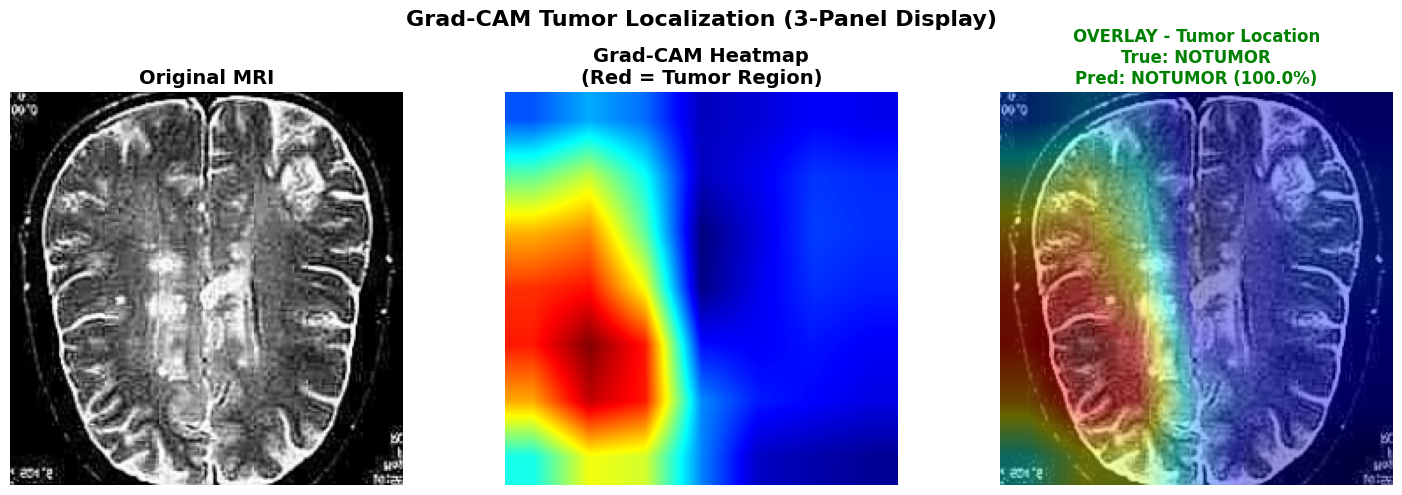


PROJECT COMPLETE

Final Accuracy: 0.9181
Outputs saved to: /kaggle/working

Check the 'gradcam_3panel_results' folder for 3-panel images with overlay!


In [1]:
"""
================================================================================
INTERPRETABLE BRAIN TUMOR CLASSIFICATION WITH 3-PANEL GRAD-CAM DISPLAY
================================================================================

This code shows:
- Panel 1: Original MRI
- Panel 2: Grad-CAM Heatmap (Red = Tumor)
- Panel 3: OVERLAY (Original + Heatmap) - Shows tumor location on the MRI

================================================================================
"""

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import DenseNet169_Weights

# Scikit-learn imports
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

# Image processing
from PIL import Image
import cv2

# ============================================================================
# EARLY STOPPING CLASS
# ============================================================================

class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='best_model.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
WORKING_DIR = "/kaggle/working"
os.makedirs(WORKING_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH = os.path.join(DATASET_PATH, "Testing")

if not os.path.exists(TRAIN_PATH):
    print("Training folder not found!")
    sys.exit(1)

CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'notumor']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001
PATIENCE = 5

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("="*80)
print("BRAIN TUMOR CLASSIFICATION WITH 3-PANEL GRAD-CAM")
print("="*80)
print(f"Classes: {CLASS_NAMES}")
print("="*80)


# ============================================================================
# 2. DATASET CLASS
# ============================================================================

class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        for class_name, class_idx in CLASS_LABELS.items():
            class_path = os.path.join(root_dir, class_name)
            if os.path.exists(class_path):
                image_files = [f for f in os.listdir(class_path) 
                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                for img_file in image_files:
                    self.images.append(os.path.join(class_path, img_file))
                    self.labels.append(class_idx)
        
        print(f"Loaded {len(self.images)} images from {root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label


# ============================================================================
# 3. MODEL ARCHITECTURE
# ============================================================================

class BrainTumorClassifier(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.5):
        super(BrainTumorClassifier, self).__init__()
        
        self.backbone = models.densenet169(weights=DenseNet169_Weights.IMAGENET1K_V1)
        num_features = self.backbone.classifier.in_features
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )
        
        self.num_classes = num_classes
    
    def forward(self, x):
        return self.backbone(x)
    
    def get_last_conv_layer(self):
        return self.backbone.features[-1]


# ============================================================================
# 4. DATA LOADERS
# ============================================================================

def get_data_loaders():
    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    
    train_dataset = BrainTumorDataset(TRAIN_PATH, transform=train_transform)
    test_dataset = BrainTumorDataset(TEST_PATH, transform=test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"\nTraining samples: {len(train_dataset)}")
    print(f"Testing samples: {len(test_dataset)}")
    
    return train_loader, test_loader, train_dataset, test_dataset


# ============================================================================
# 5. TRAINING FUNCTION
# ============================================================================

def train_model(model, train_loader, test_loader):
    print("\n" + "="*80)
    print("TRAINING MODEL")
    print("="*80 + "\n")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    early_stop = EarlyStopping(patience=PATIENCE, verbose=True)
    
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    model.to(DEVICE)
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
        for images, labels in train_pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{train_correct/train_total:.4f}'})
        
        train_epoch_loss = train_loss / len(train_loader)
        train_epoch_acc = train_correct / train_total
        train_losses.append(train_epoch_loss)
        train_accs.append(train_epoch_acc)
        
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Test]"):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
        
        test_epoch_loss = test_loss / len(test_loader)
        test_epoch_acc = test_correct / test_total
        test_losses.append(test_epoch_loss)
        test_accs.append(test_epoch_acc)
        
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print(f"  Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_acc:.4f}")
        print(f"  Test Loss:  {test_epoch_loss:.4f} | Test Acc:  {test_epoch_acc:.4f}")
        
        early_stop(test_epoch_loss, model)
        if early_stop.early_stop:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    return model, train_losses, test_losses, train_accs, test_accs


# ============================================================================
# 6. EVALUATION
# ============================================================================

def evaluate_model(model, test_loader):
    print("\n" + "="*80)
    print("MODEL EVALUATION")
    print("="*80 + "\n")
    
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    
    print(f"\nEVALUATION METRICS:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1 Score:  {f1:.4f}")
    
    results = {
        'predictions': all_preds,
        'labels': all_labels,
        'probs': all_probs,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'conf_matrix': conf_matrix
    }
    
    return results


# ============================================================================
# 7. GRAD-CAM WITH 3-PANEL DISPLAY (OVERLAY INCLUDED)
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        self.target_layer.register_forward_hook(self.save_activations)
        self.target_layer.register_backward_hook(self.save_gradients)
    
    def save_activations(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradients(self, module, input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, image, class_idx):
        self.model.eval()
        image.requires_grad_()
        
        output = self.model(image)
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()
        
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)[0]
        cam = torch.relu(cam)
        
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        
        cam = cam.unsqueeze(0).unsqueeze(0)
        cam = torch.nn.functional.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        
        return cam[0, 0].cpu().numpy()


def denormalize_image(image_tensor):
    """Convert normalized tensor back to image for display"""
    img_np = image_tensor.cpu().numpy().transpose(1, 2, 0)
    img_np = (img_np * np.array(IMAGENET_STD)) + np.array(IMAGENET_MEAN)
    img_np = np.clip(img_np, 0, 1)
    return (img_np * 255).astype(np.uint8)


def create_3_panel_gradcam_display(image_tensor, cam, true_label, pred_class, confidence):
    """
    Create 3-panel display:
    Panel 1: Original MRI
    Panel 2: Grad-CAM Heatmap (Red = Tumor region)
    Panel 3: OVERLAY (Original + Heatmap) - Shows tumor location
    """
    # Get original image
    original_img = denormalize_image(image_tensor)
    
    # Resize heatmap
    heatmap = cv2.resize(cam, (224, 224))
    
    # Create colored heatmap (Red/Yellow = high importance)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Create overlay (60% original, 40% heatmap)
    overlay = (heatmap_colored * 0.4 + original_img * 0.6).astype(np.uint8)
    
    # Create figure with 3 panels
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Panel 1: Original MRI
    axes[0].imshow(original_img)
    axes[0].set_title("Original MRI", fontsize=14, fontweight="bold")
    axes[0].axis("off")
    
    # Panel 2: Grad-CAM Heatmap
    axes[1].imshow(heatmap_colored)
    axes[1].set_title("Grad-CAM Heatmap\n(Red = Tumor Region)", fontsize=14, fontweight="bold")
    axes[1].axis("off")
    
    # Panel 3: OVERLAY (Original + Heatmap)
    axes[2].imshow(overlay)
    true_name = CLASS_NAMES[true_label]
    pred_name = CLASS_NAMES[pred_class]
    is_correct = true_label == pred_class
    
    title = f"OVERLAY - Tumor Location\nTrue: {true_name.upper()}\nPred: {pred_name.upper()} ({confidence:.1%})"
    axes[2].set_title(title, fontsize=12, fontweight="bold", 
                      color='green' if is_correct else 'red')
    axes[2].axis("off")
    
    plt.suptitle("Grad-CAM Tumor Localization (3-Panel Display)", fontsize=16, fontweight="bold")
    plt.tight_layout()
    
    return fig


def plot_gradcam_with_overlay(model, test_dataset, num_samples=4):
    """
    Generate 3-panel Grad-CAM visualizations with overlay for multiple samples.
    This is the main function you should call.
    """
    print("\n" + "="*80)
    print("GENERATING 3-PANEL GRAD-CAM WITH TUMOR LOCALIZATION")
    print("="*80)
    print("Panel 1: Original MRI")
    print("Panel 2: Grad-CAM Heatmap (Red = Tumor)")
    print("Panel 3: OVERLAY (Tumor highlighted on MRI)")
    print("="*80 + "\n")
    
    model.eval()
    target_layer = model.get_last_conv_layer()
    gradcam = GradCAM(model, target_layer)
    
    # Select samples from each class
    samples_to_show = []
    for class_idx in range(NUM_CLASSES):
        for i in range(len(test_dataset)):
            _, label = test_dataset[i]
            if label == class_idx:
                samples_to_show.append(i)
                break
    
    # Create output directory
    output_dir = os.path.join(WORKING_DIR, "gradcam_3panel_results")
    os.makedirs(output_dir, exist_ok=True)
    
    for idx, sample_idx in enumerate(samples_to_show[:num_samples]):
        image_tensor, true_label = test_dataset[sample_idx]
        image_batch = image_tensor.unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            output = model(image_batch)
            probs = torch.softmax(output, dim=1)[0]
            pred_class = output.argmax(dim=1).item()
            confidence = probs[pred_class].item()
        
        # Generate Grad-CAM
        cam = gradcam.generate_cam(image_batch, pred_class)
        
        # Create 3-panel display
        fig = create_3_panel_gradcam_display(
            image_tensor, cam, true_label, pred_class, confidence
        )
        
        # Save the figure
        true_name = CLASS_NAMES[true_label]
        pred_name = CLASS_NAMES[pred_class]
        save_path = os.path.join(output_dir, f"3panel_sample_{idx+1}_{true_name}_pred_{pred_name}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        
        plt.show()
        plt.close()


# ============================================================================
# 8. VISUALIZATION FUNCTIONS
# ============================================================================

def plot_training_curves(train_losses, test_losses, train_accs, test_accs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(train_losses) + 1)
    
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch'), ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend(), ax1.grid(alpha=0.3)
    
    ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accs, 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_xlabel('Epoch'), ax2.set_ylabel('Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend(), ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(WORKING_DIR, 'training_curves.png'), dpi=300)
    plt.close()
    print("Saved: training_curves.png")


def plot_confusion_matrix(conf_matrix):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=[c.upper() for c in CLASS_NAMES],
                yticklabels=[c.upper() for c in CLASS_NAMES],
                ax=ax, annot_kws={'size': 14})
    
    ax.set_xlabel('Predicted Label'), ax.set_ylabel('True Label')
    ax.set_title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(WORKING_DIR, 'confusion_matrix.png'), dpi=300)
    plt.close()
    print("Saved: confusion_matrix.png")


def plot_roc_curves(results):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    labels = results['labels']
    probs = results['probs']
    
    for i, class_name in enumerate(CLASS_NAMES):
        binary_labels = (labels == i).astype(int)
        fpr, tpr, _ = roc_curve(binary_labels, probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{class_name.upper()} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_xlabel('False Positive Rate'), ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves'), ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(WORKING_DIR, 'roc_curves.png'), dpi=300)
    plt.close()
    print("Saved: roc_curves.png")


def plot_sample_predictions(model, test_dataset, results, num_samples=6):
    """Plot sample predictions with confidence scores"""
    model.eval()
    
    indices = np.linspace(0, len(test_dataset)-1, num_samples, dtype=int)
    
    rows = 2
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, sample_idx in enumerate(indices):
        if idx >= len(axes):
            break
        
        image_tensor, true_label = test_dataset[sample_idx]
        image_batch = image_tensor.unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            output = model(image_batch)
            probs = torch.softmax(output, dim=1)[0]
            pred_class = output.argmax(dim=1).item()
            confidence = probs[pred_class].item()
        
        img_np = denormalize_image(image_tensor)
        
        ax = axes[idx]
        ax.imshow(img_np)
        
        true_name = CLASS_NAMES[true_label]s
        pred_name = CLASS_NAMES[pred_class]
        
        title = f"True: {true_name.upper()}\nPred: {pred_name.upper()}\nConf: {confidence:.1%}"
        if true_label == pred_class:
            ax.set_title(title, fontsize=10, fontweight='bold', color='green')
        else:
            ax.set_title(title, fontsize=10, fontweight='bold', color='red')
        
        ax.axis('off')
    
    plt.suptitle("Sample Test Predictions", fontsize=14, fontweight="bold")
    plt.tight_layout()
    
    save_path = os.path.join(WORKING_DIR, 'sample_predictions.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ============================================================================
# 9. MAIN
# ============================================================================

def main():
    try:
        # Check dataset
        if not os.path.exists(DATASET_PATH):
            print(f"Dataset not found at {DATASET_PATH}")
            return
        
        # Load data
        train_loader, test_loader, train_dataset, test_dataset = get_data_loaders()
        
        if len(train_dataset) == 0:
            print("No training images found!")
            return
        
        # Create model
        model = BrainTumorClassifier(num_classes=NUM_CLASSES)
        total_params = sum(p.numel() for p in model.parameters())
        print(f"\nModel parameters: {total_params:,}")
        
        # Train
        model, train_losses, test_losses, train_accs, test_accs = train_model(
            model, train_loader, test_loader
        )
        
        # Evaluate
        results = evaluate_model(model, test_loader)
        
        # Visualizations
        plot_training_curves(train_losses, test_losses, train_accs, test_accs)
        plot_confusion_matrix(results['conf_matrix'])
        plot_roc_curves(results)
        plot_sample_predictions(model, test_dataset, results, num_samples=6)
        
        # IMPORTANT: This generates the 3-panel Grad-CAM with OVERLAY
        plot_gradcam_with_overlay(model, test_dataset, num_samples=4)
        
        # Save model
        torch.save(model.state_dict(), os.path.join(WORKING_DIR, 'brain_tumor_classifier.pth'))
        
        print("\n" + "="*80)
        print("PROJECT COMPLETE")
        print("="*80)
        print(f"\nFinal Accuracy: {results['accuracy']:.4f}")
        print(f"Outputs saved to: {WORKING_DIR}")
        print("\nCheck the 'gradcam_3panel_results' folder for 3-panel images with overlay!")
        
    except Exception as e:
        print(f"\nERROR: {str(e)}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()